In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from numpy.ma.core import shape

warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

EDA

In [133]:
# Load dataset
df = pd.read_csv(r"E:\Data Science classes\Assignments\Questions\7. MLR\Multiple Linear Regression\ToyotaCorolla - MLR.csv")

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()

Dataset Shape: (1436, 11)

Column Names: ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [134]:
df.duplicated().sum()

np.int64(1)

In [135]:
df[df.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [136]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [139]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

Outliers

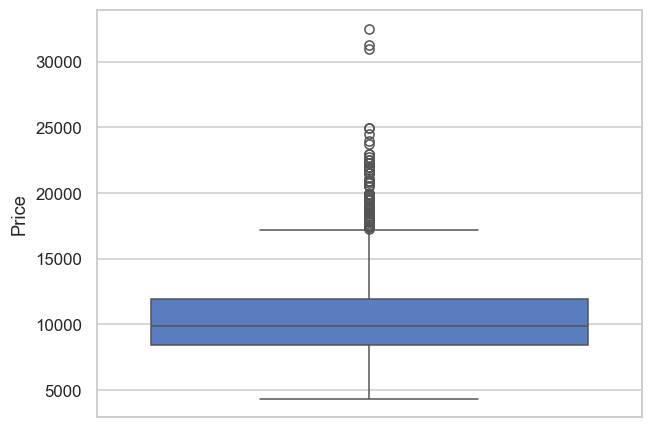

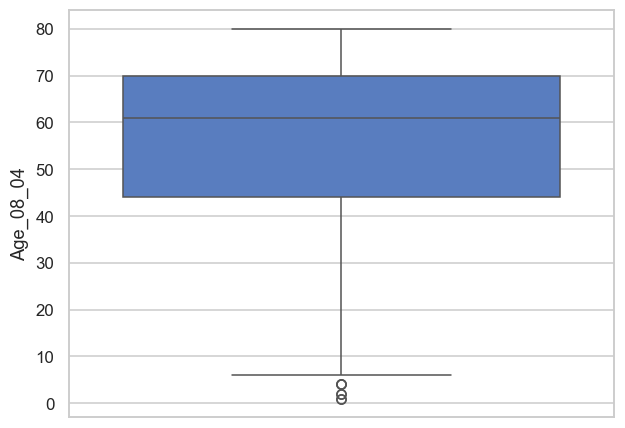

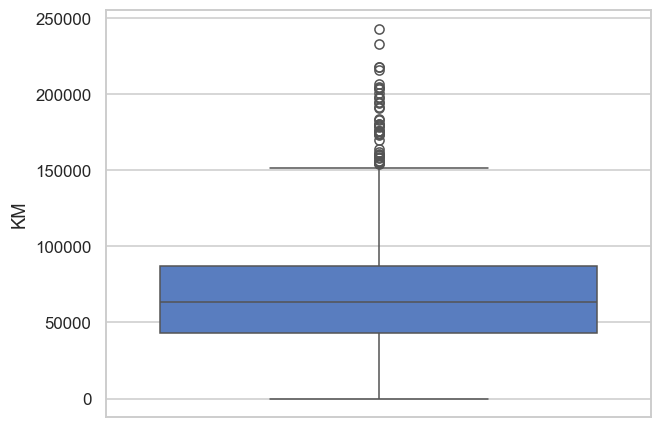

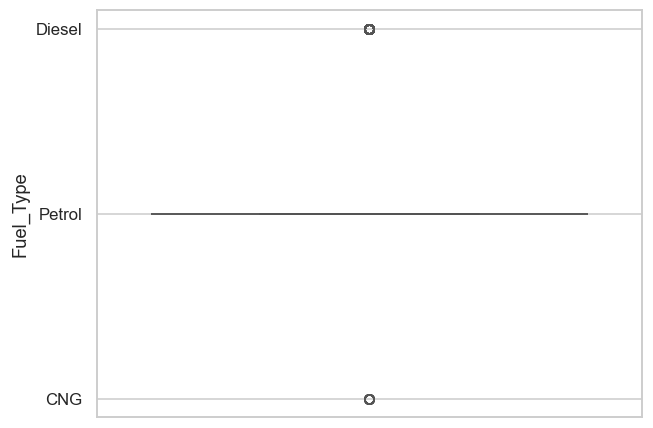

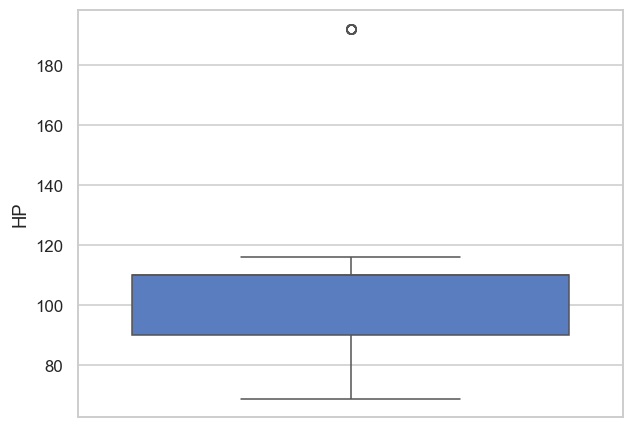

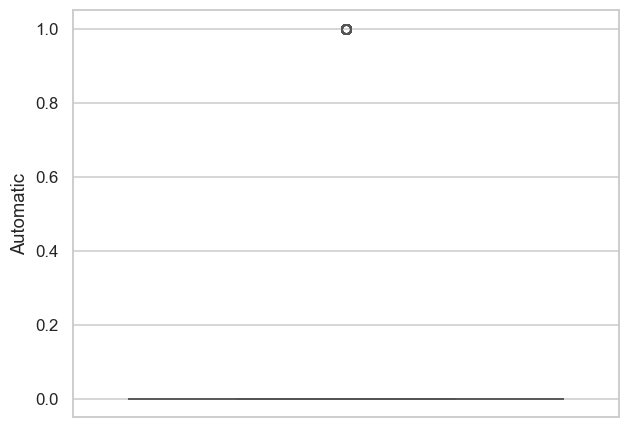

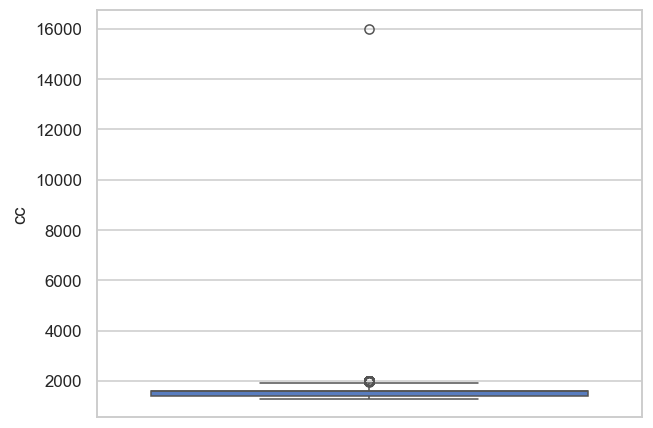

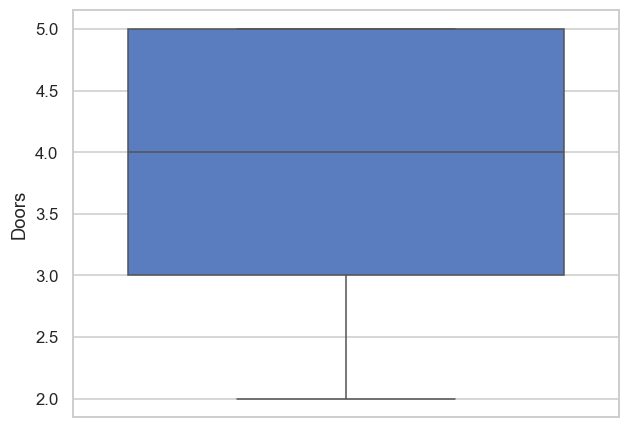

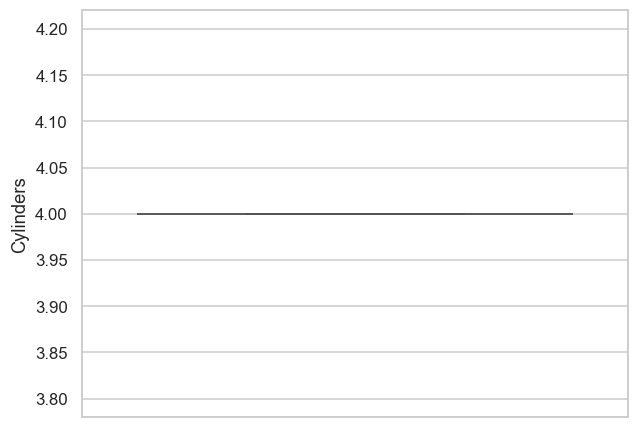

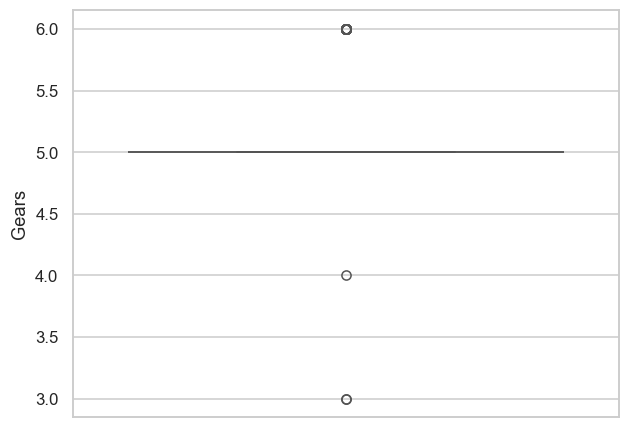

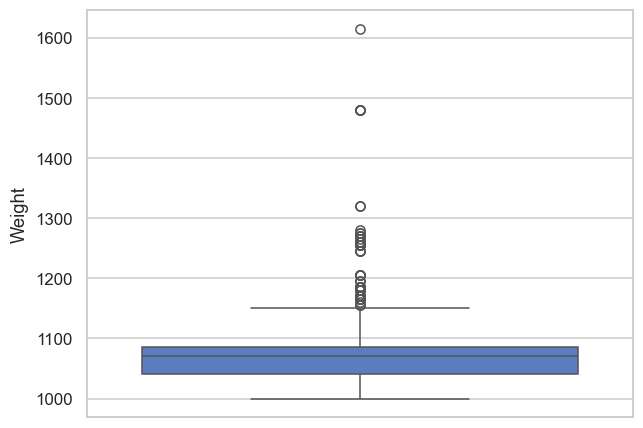

In [140]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [164]:
def outlier_capping(df,column):
    Q1 = np.percentile(df[column], 25)
    Q3 = np.percentile(df[column], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

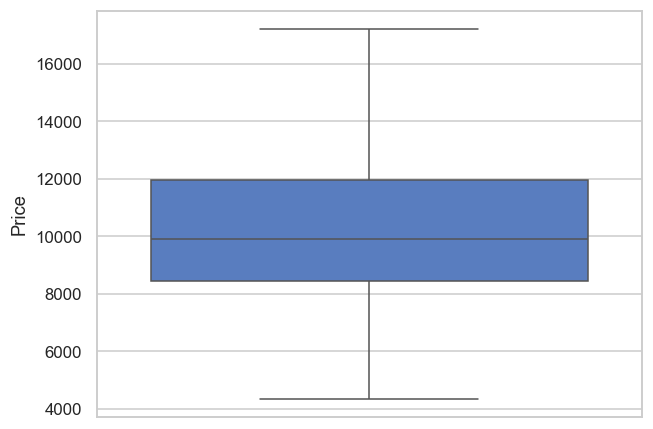

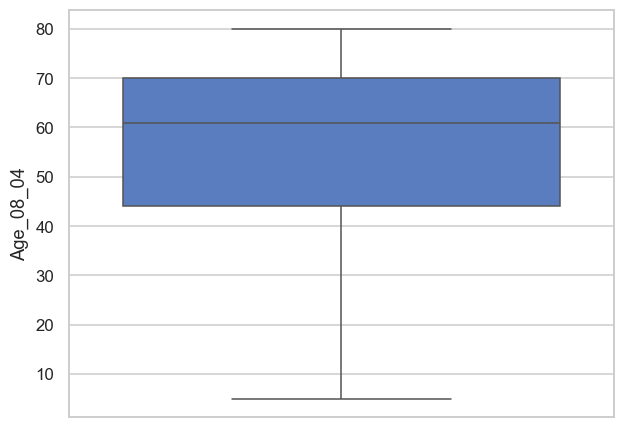

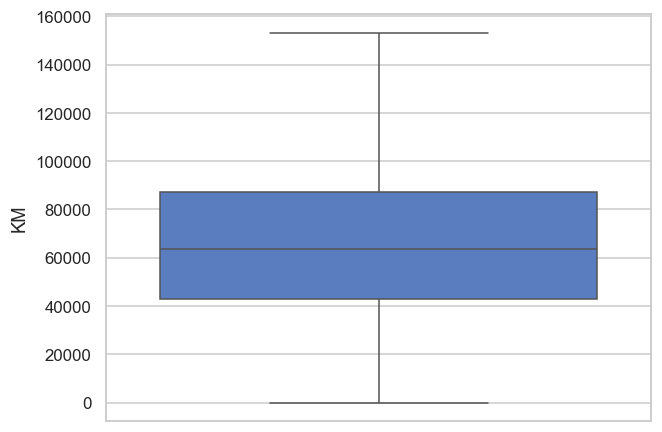

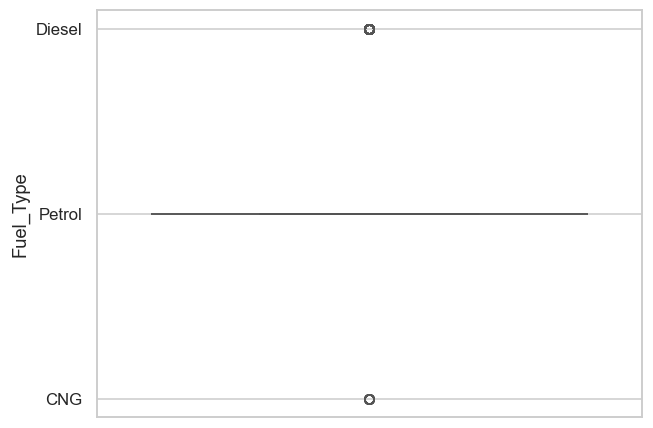

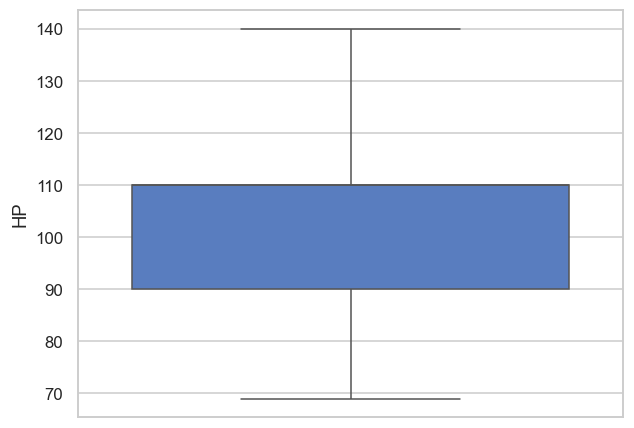

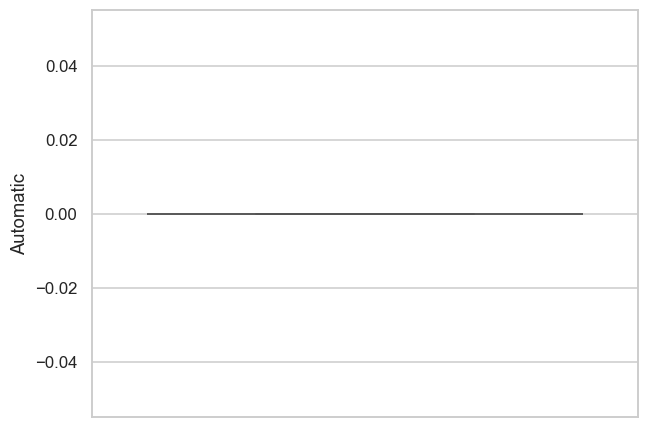

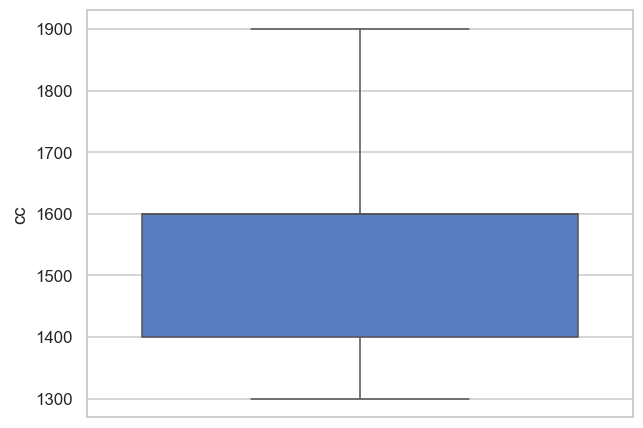

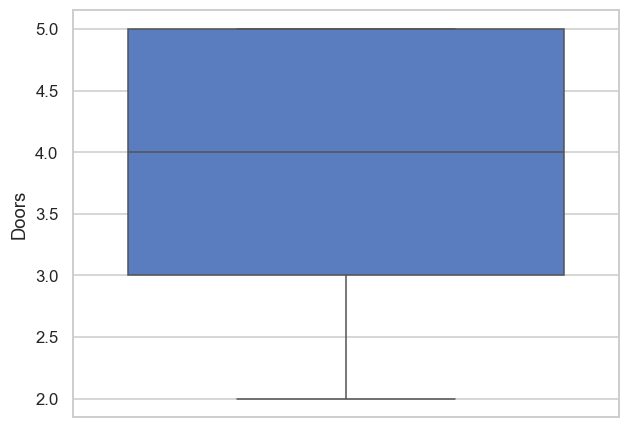

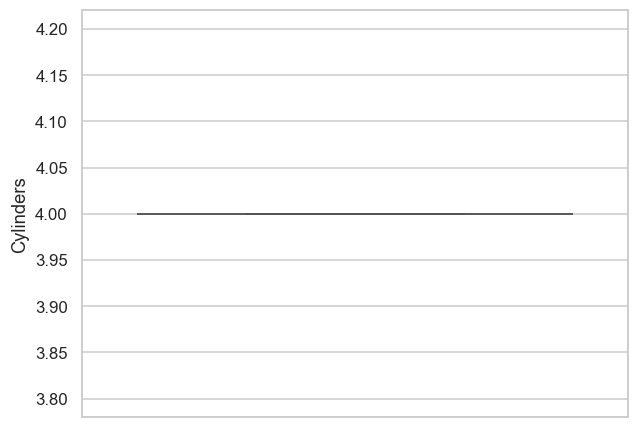

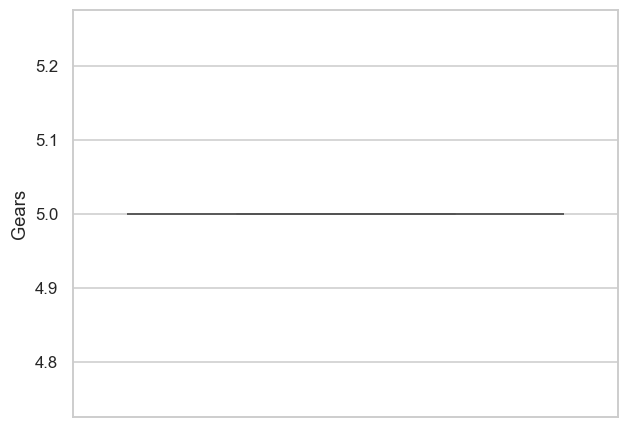

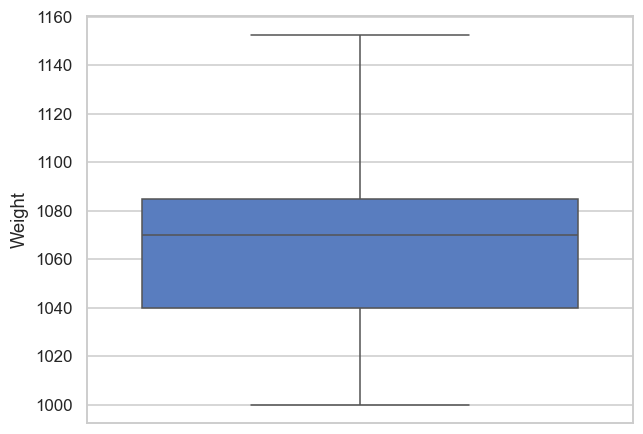

In [165]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

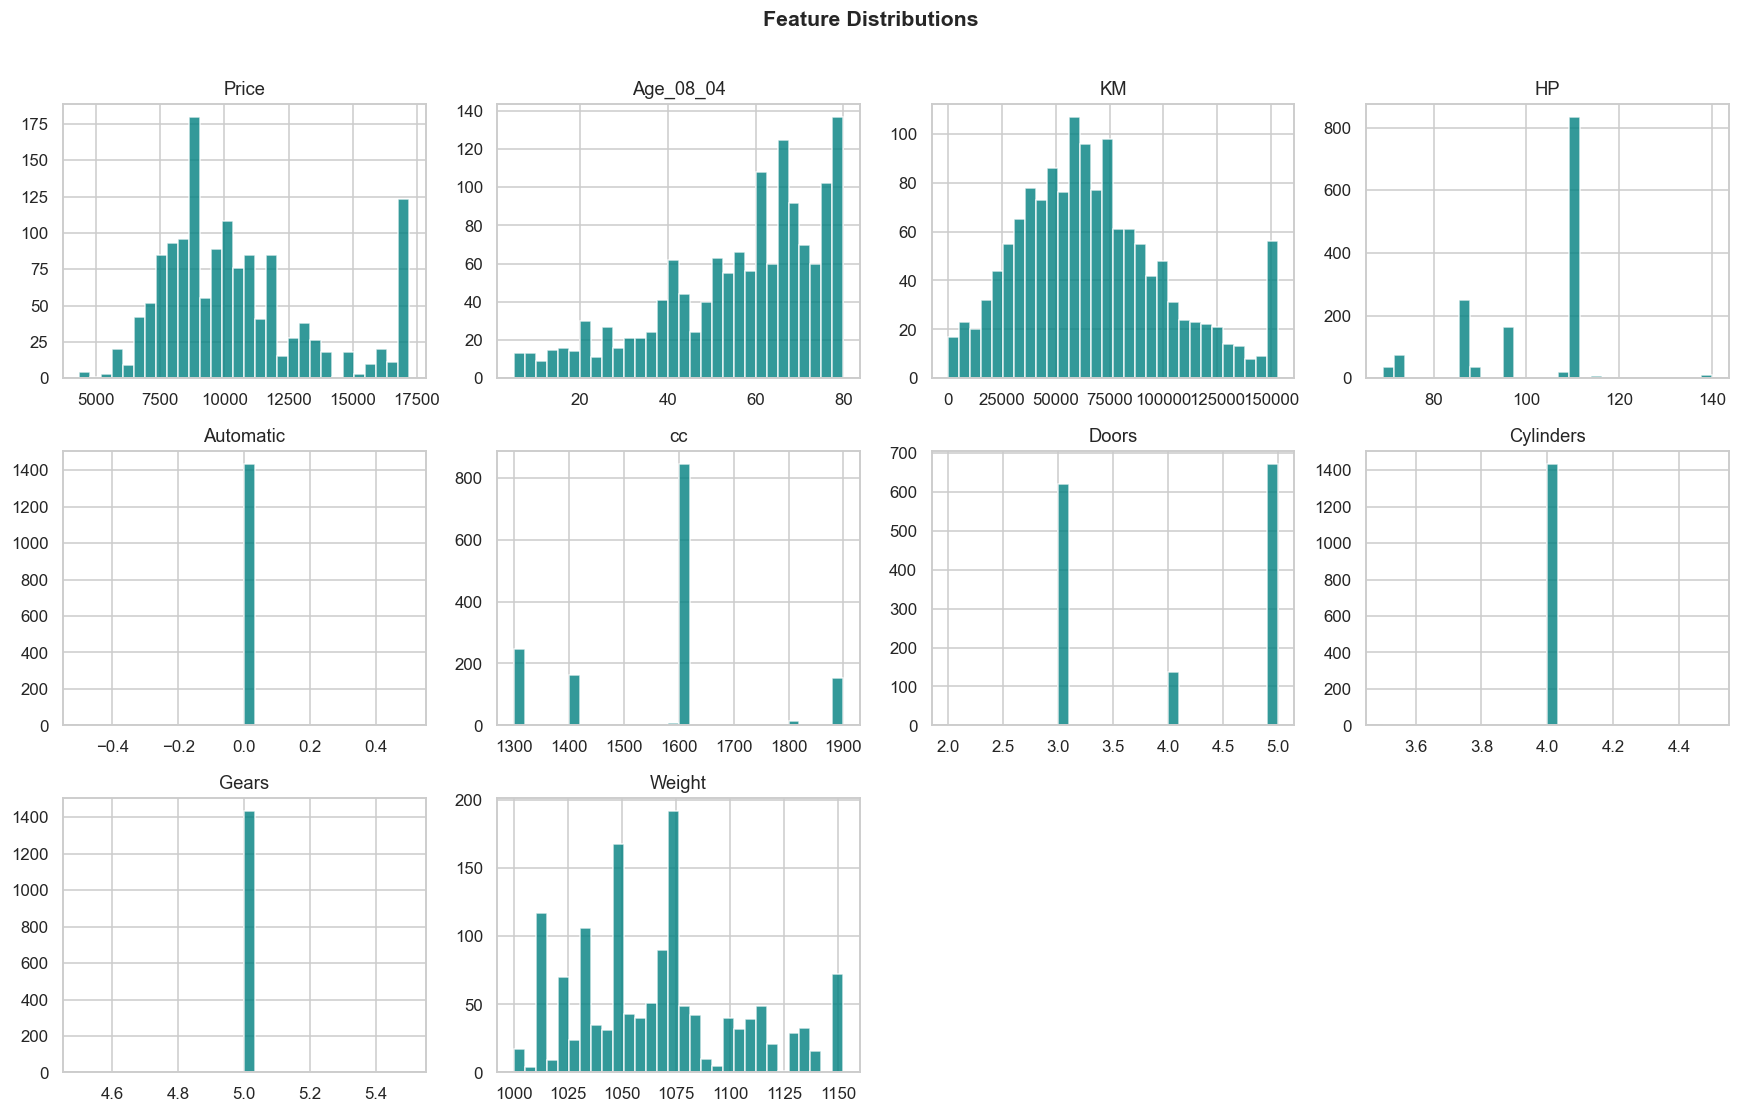

In [143]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

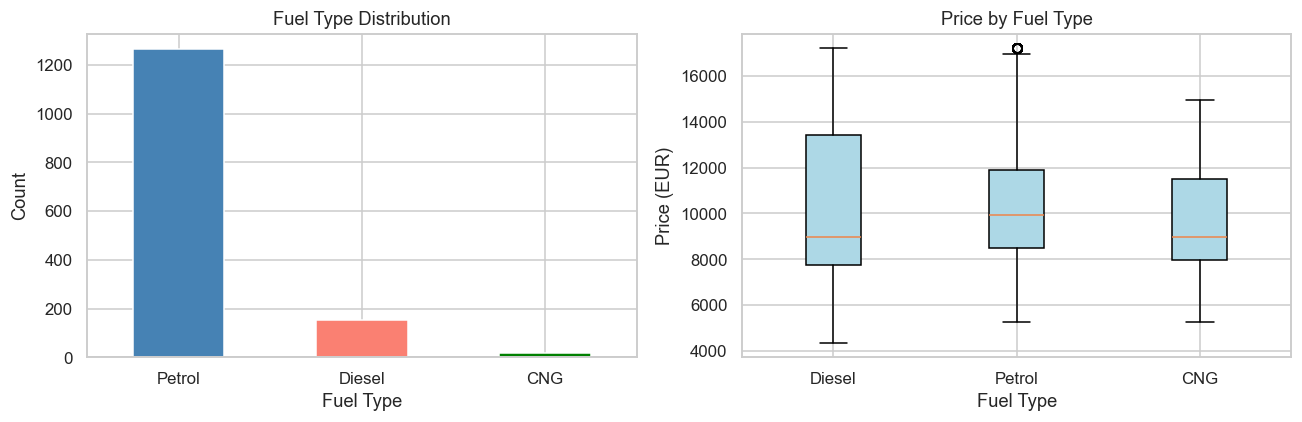

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Fuel_Type'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon','green'],
                                    edgecolor='white')
axes[0].set_title('Fuel Type Distribution')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Boxplot of price by fuel type
fuel_groups = [df[df['Fuel_Type'] == ft]['Price'].values for ft in df['Fuel_Type'].unique()]
axes[1].boxplot(fuel_groups, labels=df['Fuel_Type'].unique(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Price by Fuel Type')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Price (EUR)')

plt.tight_layout()
plt.show()

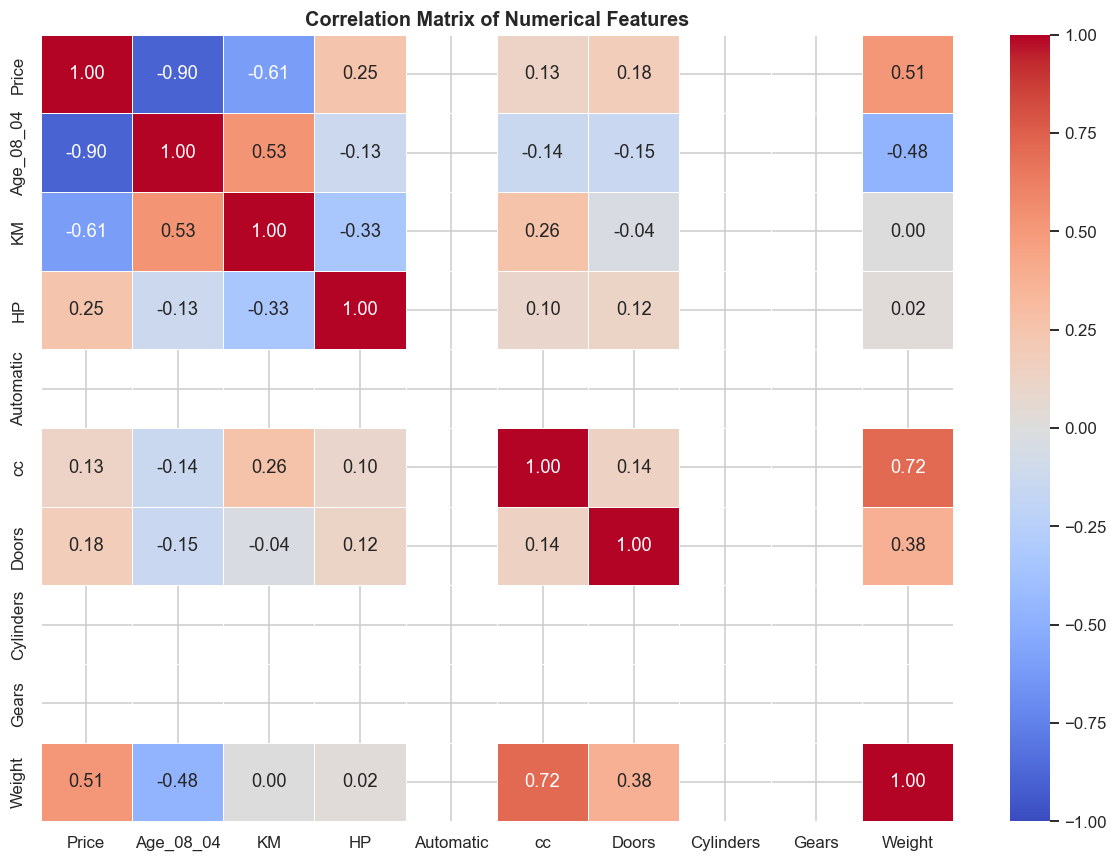

In [145]:
plt.figure(figsize=(11, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

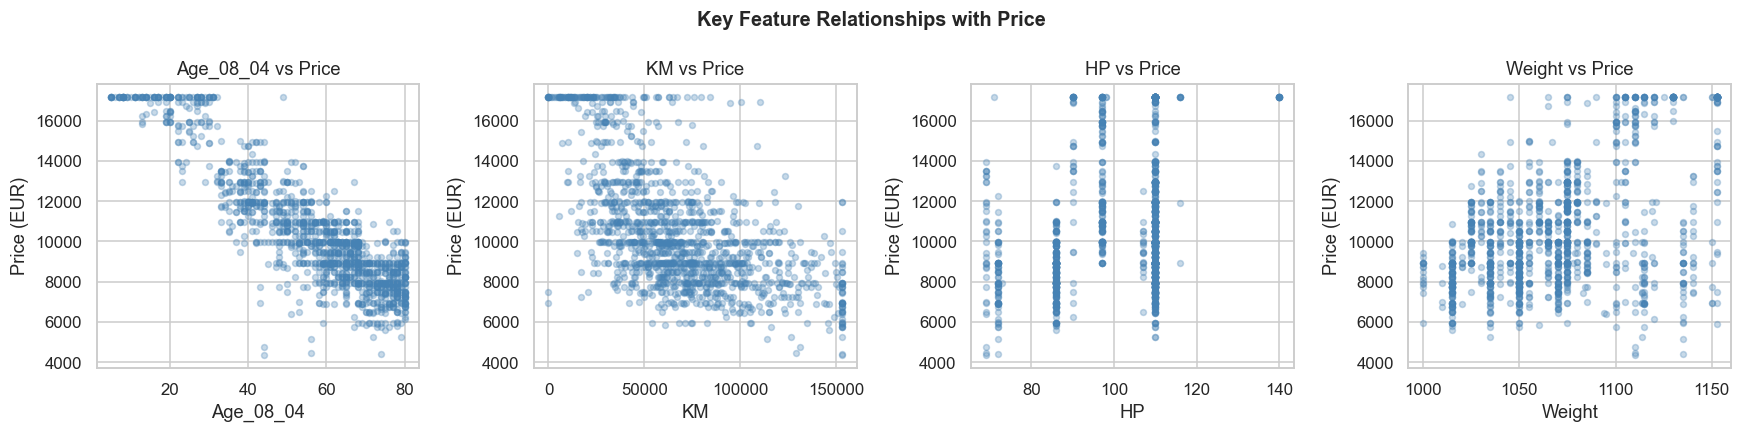

In [146]:
key_features = ['Age_08_04', 'KM', 'HP', 'Weight']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(key_features):
    axes[i].scatter(df[feat], df['Price'], alpha=0.3, color='steelblue', s=15)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price (EUR)')
    axes[i].set_title(f'{feat} vs Price')

plt.suptitle('Key Feature Relationships with Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [147]:
df_encoded = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True, dtype=int)

print('Columns after encoding:', df_encoded.columns.tolist())
df_encoded.head()

Columns after encoding: ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,1,0
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,1,0
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,1,0
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,1,0
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,1,0


In [148]:
# IQR-based outlier detection on Price
Q1 = df_encoded['Price'].quantile(0.25)
Q3 = df_encoded['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = df_encoded[(df_encoded['Price'] < lower_bound) | (df_encoded['Price'] > upper_bound)]
print(f'Outliers found (Price): {len(outliers)}')
print(f'Lower Bound: {lower_bound:.0f}, Upper Bound: {upper_bound:.0f}')

# Remove extreme outliers
df_clean = df_encoded[(df_encoded['Price'] >= lower_bound) & (df_encoded['Price'] <= upper_bound)].copy()
print(f'Shape after removing outliers: {df_clean.shape}')

Outliers found (Price): 0
Lower Bound: -2050, Upper Bound: 22450
Shape after removing outliers: (1435, 12)


In [149]:
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

print('Feature Matrix shape:', X.shape)
print('Target vector shape:', y.shape)
print('Features used:', X.columns.tolist())

Feature Matrix shape: (1435, 11)
Target vector shape: (1435,)
Features used: ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


In [150]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Training Set : X={x_train.shape}, Y={y_train.shape}')
print(f'Test Set : X={x_test.shape}, Y={y_test.shape}')


Training Set : X=(1148, 11), Y=(1148,)
Test Set : X=(287, 11), Y=(287,)


In [151]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled  = scaler.transform(x_test)

In [152]:
vif_data = pd.DataFrame()
vif_data['Features'] = x_train.columns
vif_data['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif_data = vif_data.sort_values(by=['VIF'], ascending=False).reset_index(drop=True)

print('VIF > 10 indicates high multicollinearity:')
print(vif_data.to_string(index=False))

VIF > 10 indicates high multicollinearity:
        Features       VIF
Fuel_Type_Diesel 27.159627
              cc 12.561670
Fuel_Type_Petrol 10.312009
              HP  9.840913
          Weight  3.943337
       Age_08_04  2.205494
              KM  2.057854
           Doors  1.300281
       Cylinders  0.000000
           Gears  0.000000
       Automatic       NaN


In [153]:
def evaluate_model(model_name, y_true, y_pred):
    """Print evaluation metrics for a regression model."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n--- {model_name} ---')
    print(f'  MAE  : {mae:,.2f}')
    print(f'  MSE  : {mse:,.2f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  R²   : {r2:.4f}')
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []  # Collect results for final comparison

In [154]:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)

res1=evaluate_model('Model 1: MLR (All Features)', y_test, y_pred1)
results.append(res1)

coef_df1 = pd.DataFrame({'Feature': x_train.columns, 'Coefficient': model1.coef_})
coef_df1 = coef_df1.sort_values(by=['Coefficient'],key=abs, ascending=False)
print('Coefficient:')
print(coef_df1.to_string(index=False))


--- Model 1: MLR (All Features) ---
  MAE  : 874.11
  MSE  : 1,275,108.72
  RMSE : 1,129.21
  R²   : 0.8505
Coefficient:
         Feature   Coefficient
       Age_08_04 -1.958916e+03
          Weight  9.765952e+02
              KM -5.158060e+02
              cc -4.627095e+02
              HP  3.946400e+02
Fuel_Type_Petrol  3.292560e+02
Fuel_Type_Diesel  2.957303e+02
           Doors -1.221588e+02
       Automatic -3.154810e-12
       Cylinders -1.563194e-13
           Gears  0.000000e+00


In [155]:
# Detailed OLS Summary via Statsmodels
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     944.1
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        11:11:26   Log-Likelihood:                -9650.1
No. Observations:                1148   AIC:                         1.932e+04
Df Residuals:                    1139   BIC:                         1.936e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.049e+04     32.075    327.040      0.0

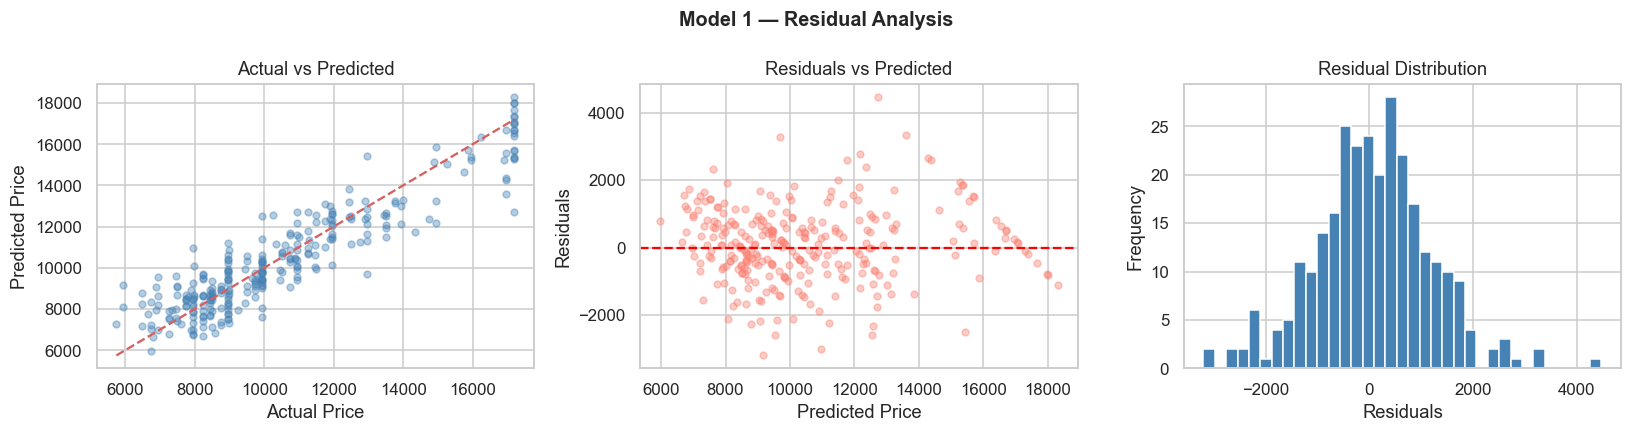

In [156]:
residuals1 = y_test - y_pred1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred1, alpha=0.4, color='steelblue', s=20)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Price'); axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted')

# Residuals vs Predicted
axes[1].scatter(y_pred1, residuals1, alpha=0.4, color='salmon', s=20)
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Price'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

# Distribution of Residuals
axes[2].hist(residuals1, bins=35, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Residuals'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.suptitle('Model 1 — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [157]:
#Model 2

corr_with_price = df_clean.corr()['Price'].drop('Price').abs()
top_features = corr_with_price[corr_with_price > 0.15].index.tolist()
print("selected Features( |Corr| > 0.15): ", top_features)

x_train2 = x_train[top_features]
x_test2 = x_test[top_features]

scaler2 = StandardScaler()
x_train2_scaled = scaler2.fit_transform(x_train2)
x_test2_scaled = scaler2.transform(x_test2)



model2 = LinearRegression()
model2.fit(x_train2_scaled, y_train)
y_pred2 = model2.predict(x_test2_scaled)
res2=evaluate_model('Model 2: MLR (Top Corr. Features)', y_test, y_pred2)
results.append(res2)

selected Features( |Corr| > 0.15):  ['Age_08_04', 'KM', 'HP', 'Doors', 'Weight']

--- Model 2: MLR (Top Corr. Features) ---
  MAE  : 895.10
  MSE  : 1,308,819.66
  RMSE : 1,144.04
  R²   : 0.8465


In [158]:
#Model3

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
x_train3=poly.fit_transform(x_train2_scaled)
x_test3=poly.transform(x_test2_scaled)

print(f"Features after PolynomialFeatures(deg = 2):{x_train3.shape[1]} ")

model3 = LinearRegression()
model3.fit(x_train3, y_train)
y_pred3 = model3.predict(x_test3)
res3=evaluate_model('Model 3: MLR + Polynomial Features (deg=2)', y_test, y_pred3)
results.append(res3)

Features after PolynomialFeatures(deg = 2):20 

--- Model 3: MLR + Polynomial Features (deg=2) ---
  MAE  : 888.96
  MSE  : 1,292,197.51
  RMSE : 1,136.75
  R²   : 0.8485


In [159]:
from sklearn.linear_model import RidgeCV

# Cross-validate to find best alpha
alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 200]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print(f'Best Ridge alpha: {ridge_cv.alpha_}')

ridge_model = Ridge(alpha=ridge_cv.alpha_)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
res_ridge = evaluate_model('Ridge Regression', y_test, y_pred_ridge)
results.append(res_ridge)

# Ridge Coefficients
ridge_coef = pd.DataFrame({'Feature': x_train.columns, 'Ridge_Coef': ridge_model.coef_})
ridge_coef = ridge_coef.sort_values('Ridge_Coef', key=abs, ascending=False)
print('\nRidge Coefficients:')
print(ridge_coef.to_string(index=False))

Best Ridge alpha: 0.01

--- Ridge Regression ---
  MAE  : 874.11
  MSE  : 1,275,112.71
  RMSE : 1,129.21
  R²   : 0.8505

Ridge Coefficients:
         Feature   Ridge_Coef
       Age_08_04 -1958.902614
          Weight   976.576459
              KM  -515.827032
              cc  -462.597055
              HP   394.549227
Fuel_Type_Petrol   329.193523
Fuel_Type_Diesel   295.555231
           Doors  -122.152067
       Automatic     0.000000
       Cylinders     0.000000
           Gears     0.000000


In [160]:
from sklearn.linear_model import LassoCV

# Cross-validate to find best alpha
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
print(f'Best Lasso alpha: {lasso_cv.alpha_}')

lasso_model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
res_lasso = evaluate_model('Lasso Regression', y_test, y_pred_lasso)
results.append(res_lasso)

# Lasso Coefficients — shows feature selection (zeroed-out features)
lasso_coef = pd.DataFrame({'Feature': x_train.columns, 'Lasso_Coef': lasso_model.coef_})
lasso_coef = lasso_coef.sort_values('Lasso_Coef', key=abs, ascending=False)
print('\nLasso Coefficients (0 = feature eliminated):')
print(lasso_coef.to_string(index=False))

Best Lasso alpha: 0.01

--- Lasso Regression ---
  MAE  : 874.11
  MSE  : 1,275,114.04
  RMSE : 1,129.21
  R²   : 0.8505

Lasso Coefficients (0 = feature eliminated):
         Feature   Lasso_Coef
       Age_08_04 -1958.943350
          Weight   976.542135
              KM  -515.833091
              cc  -462.336762
              HP   394.322287
Fuel_Type_Petrol   329.050299
Fuel_Type_Diesel   295.111805
           Doors  -122.138755
       Automatic     0.000000
       Cylinders     0.000000
           Gears     0.000000


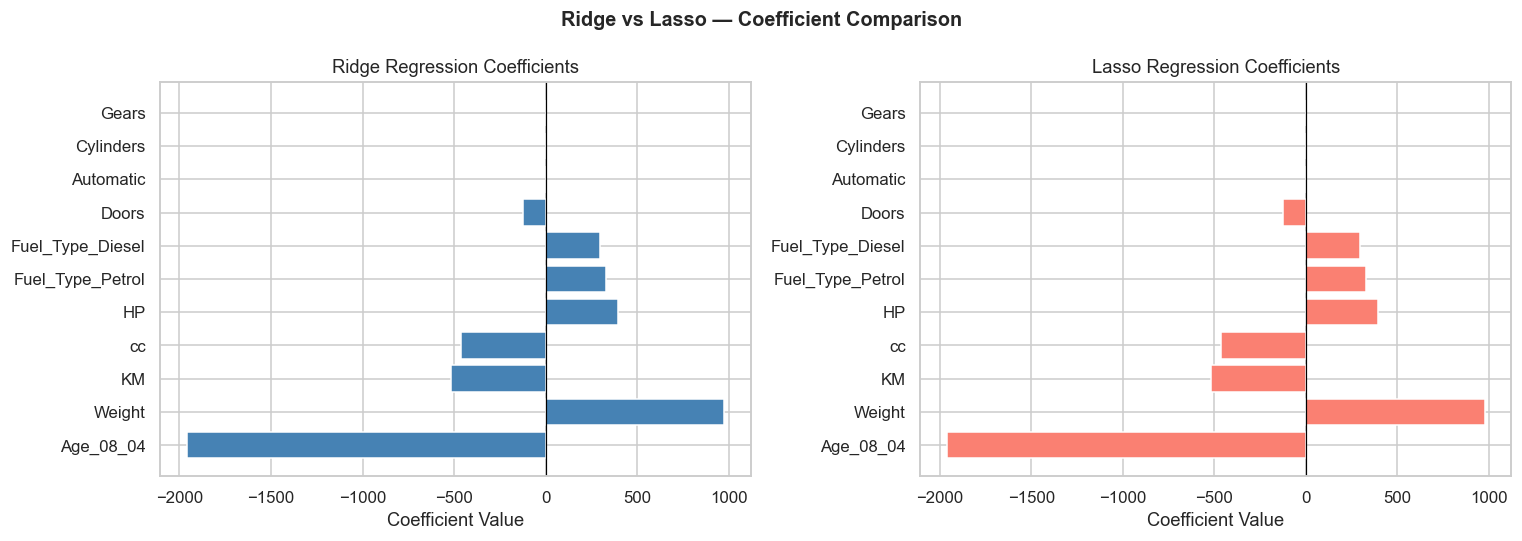

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].barh(ridge_coef['Feature'], ridge_coef['Ridge_Coef'], color='steelblue')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Ridge Regression Coefficients')
axes[0].set_xlabel('Coefficient Value')

# Lasso
axes[1].barh(lasso_coef['Feature'], lasso_coef['Lasso_Coef'], color='salmon')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Lasso Regression Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Ridge vs Lasso — Coefficient Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [162]:
# Summary DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R2', ascending=False).reset_index(drop=True)
print('\n===== MODEL COMPARISON =====')
print(comparison_df.to_string(index=False))


===== MODEL COMPARISON =====
                                     Model        MAE        RMSE       R2
               Model 1: MLR (All Features) 874.113042 1129.207119 0.850484
                          Ridge Regression 874.113948 1129.208889 0.850484
                          Lasso Regression 874.114984 1129.209477 0.850484
Model 3: MLR + Polynomial Features (deg=2) 888.963844 1136.748656 0.848480
         Model 2: MLR (Top Corr. Features) 895.104263 1144.036566 0.846531


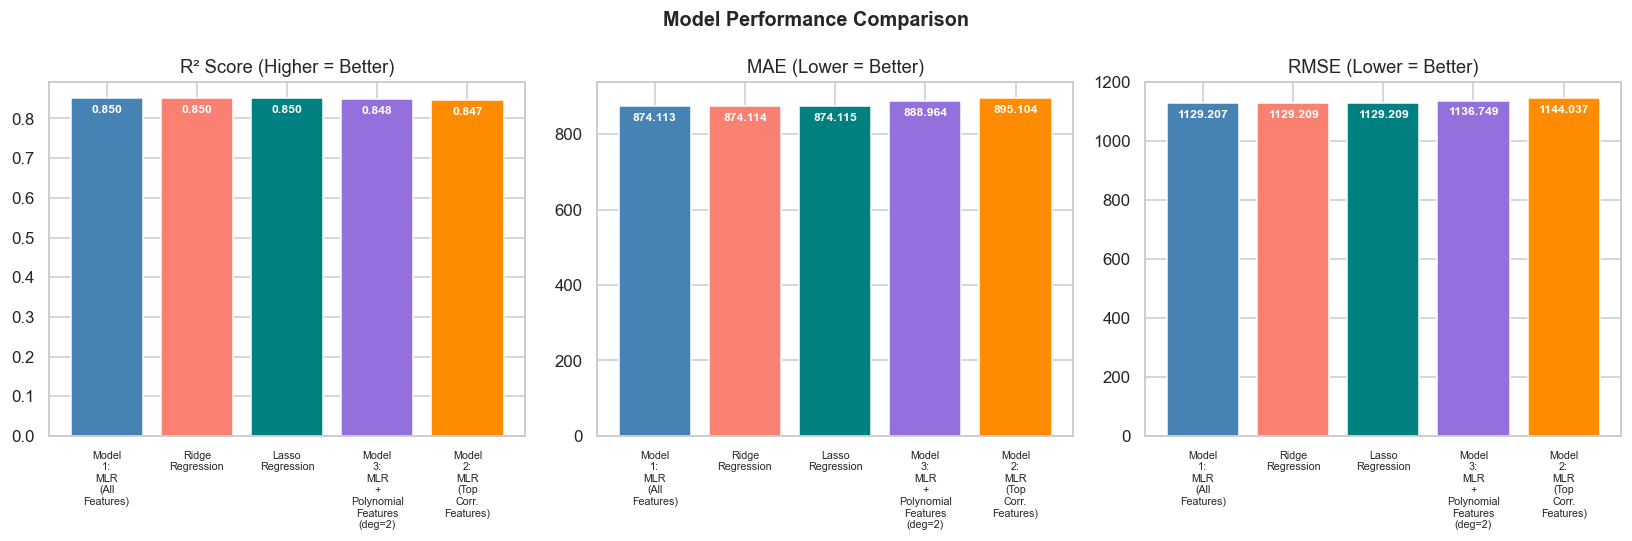

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'salmon', 'teal', 'mediumpurple', 'darkorange']

metrics = ['R2', 'MAE', 'RMSE']
titles  = ['R² Score (Higher = Better)', 'MAE (Lower = Better)', 'RMSE (Lower = Better)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    bars = axes[i].bar(range(len(comparison_df)), comparison_df[metric],
                       color=colors[:len(comparison_df)], edgecolor='white')
    axes[i].set_xticks(range(len(comparison_df)))
    axes[i].set_xticklabels([m.replace(' ', '\n') for m in comparison_df['Model']],
                             fontsize=7)
    axes[i].set_title(title)
    for bar, val in zip(bars, comparison_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.98,
                     f'{val:.3f}', ha='center', va='top', fontsize=8, color='white', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Interview Questions

### Q1. What is Normalization & Standardization and how is it helpful?

**Normalization (Min-Max Scaling):**
Rescales every feature to a fixed range, typically [0, 1], using:
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
- Useful when features need to be on the same bounded scale (e.g., neural networks, KNN).
- Sensitive to outliers.

**Standardization (Z-score Scaling):**
Transforms each feature to have mean = 0 and standard deviation = 1:
$$X_{std} = \frac{X - \mu}{\sigma}$$
- Preferred for linear models, SVMs, PCA.
- Robust to outliers compared to normalization.

**Why it's helpful in MLR:**
- Makes regression coefficients comparable in magnitude.
- Speeds up convergence in gradient-based optimization.
- Improves stability of regularized models (Ridge, Lasso).

---

### Q2. What techniques can be used to address multicollinearity in Multiple Linear Regression?

Multicollinearity occurs when independent variables are highly correlated with each other, inflating standard errors and making coefficients unstable.

**Detection:**
- Correlation matrix
- Variance Inflation Factor (VIF) — VIF > 10 indicates severe multicollinearity

**Remediation Techniques:**

| Technique | Description |
|---|---|
| **Remove correlated features** | Drop one of two highly correlated predictors |
| **Principal Component Analysis (PCA)** | Transform correlated features into orthogonal components |
| **Ridge Regression (L2)** | Penalizes large coefficients, shrinks all to small values |
| **Lasso Regression (L1)** | Penalizes large coefficients, can zero out irrelevant features |
| **Feature engineering** | Combine correlated variables into one (e.g., ratio, mean) |
| **Increase sample size** | More data stabilizes coefficient estimates |

In this project, **Ridge and Lasso** were applied to handle multicollinearity while retaining all features.